# 03. Preprocesamiento y reducción de dimensionalidad
Fase 3 del proyecto. Se prepara el dataset **Airline Passenger Satisfaction** para un futuro modelado mediante
codificación de variables categóricas, escalado de variables numéricas y reducción de dimensionalidad (PCA y t-SNE).
Las decisiones se basan en los resultados del EDA (`02_eda.ipynb`).

## 1. Carga de datos

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer

sns.set_style('whitegrid')

path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
df_train = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))
df = pd.concat([df_train, df_test], ignore_index=True)

print(df.shape)

(129880, 25)


## 2. Limpieza

Se aplican las mismas decisiones del EDA:
- Eliminación de `Unnamed: 0` (índice de los archivos originales) e `id` (identificador sin valor analítico).
- Imputación de los 393 faltantes de `Arrival Delay in Minutes` con la mediana, dado el sesgo de la variable.

In [ ]:
df = df.drop(columns=['Unnamed: 0', 'id'])
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

print(df.shape)
print("Faltantes restantes:", df.isnull().sum().sum())

(129880, 23)
Faltantes restantes: 0


**Nota:** la imputación y el escalado se ajustan aquí sobre todo el dataset con fines exploratorios. En la fase de modelado deben ajustarse
solo con el conjunto de entrenamiento para evitar fuga de datos.

## 3. Variable objetivo

`satisfaction` se codifica como 1 (satisfecho) y 0 (neutral o insatisfecho).

In [ ]:
y = (df['satisfaction'] == 'satisfied').astype(int)
X = df.drop(columns=['satisfaction'])

print(y.value_counts())
print("\nProporción de satisfechos:", round(y.mean(), 3))

satisfaction
0    73452
1    56428
Name: count, dtype: int64

Proporción de satisfechos: 0.434


El 43% de los pasajeros está satisfecho; no se considera un desbalance que requiera tratamiento.

## 4. Grupos de variables

In [ ]:
nominales = ['Gender', 'Customer Type', 'Type of Travel']
ordinales = ['Class']
delays = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']
continuas = ['Age', 'Flight Distance']
calificaciones = [c for c in X.columns if c not in nominales + ordinales + delays + continuas]

print("Calificaciones (0-5):", len(calificaciones))
for col in nominales + ordinales:
    print(f"{col}: {X[col].unique().tolist()}")

Calificaciones (0-5): 14
Gender: ['Male', 'Female']
Customer Type: ['Loyal Customer', 'disloyal Customer']
Type of Travel: ['Personal Travel', 'Business travel']
Class: ['Eco Plus', 'Business', 'Eco']


| Grupo | Variables | Tratamiento |
|---|---|---|
| Nominales (binarias) | `Gender`, `Customer Type`, `Type of Travel` | One-Hot |
| Ordinal | `Class` (Eco < Eco Plus < Business) | Codificación ordinal + escalado |
| Delays | `Departure Delay`, `Arrival Delay` (skewness ≈ 6.8) | `log1p` + escalado |
| Continuas | `Age`, `Flight Distance` | Escalado |
| Calificaciones | 14 preguntas de encuesta (0 a 5) | Escalado |

## 5. Codificación de variables categóricas

### Variables nominales: One-Hot

Las tres variables son binarias, por lo que se usa `drop='if_binary'` para obtener una sola columna 0/1 por variable y evitar columnas redundantes.

In [ ]:
onehot = OneHotEncoder(drop='if_binary', sparse_output=False)
nominales_cod = pd.DataFrame(onehot.fit_transform(X[nominales]),
                             columns=onehot.get_feature_names_out(nominales))

pd.concat([X[nominales].head(), nominales_cod.head()], axis=1)

,Gender,Customer Type,Type of Travel,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel
0,Male,Loyal Customer,Personal Travel,1.0,0.0,1.0
1,Male,disloyal Customer,Business travel,1.0,1.0,0.0
2,Female,Loyal Customer,Business travel,0.0,0.0,0.0
3,Female,Loyal Customer,Business travel,0.0,0.0,0.0
4,Male,Loyal Customer,Business travel,1.0,0.0,0.0


### Variable ordinal: `Class`

`Class` se codifica de forma ordinal (Eco = 0, Eco Plus = 1, Business = 2) para conservar la jerarquía entre clases.
El orden se define explícitamente, ya que por defecto sklearn lo asigna alfabéticamente.

In [ ]:
ordinal = OrdinalEncoder(categories=[['Eco', 'Eco Plus', 'Business']])
clase_cod = ordinal.fit_transform(X[ordinales])

pd.DataFrame({'Class': X['Class'].head(8), 'Class codificada': clase_cod[:8, 0]})

,Class,Class codificada
0,Eco Plus,1.0
1,Business,2.0
2,Business,2.0
3,Business,2.0
4,Business,2.0
5,Eco,0.0
6,Eco,0.0
7,Business,2.0


### Variables de calificación

Las 14 calificaciones son numéricas y ordinales, por lo que se conservan como numéricas. Aplicar One-Hot generaría 84 columnas y eliminaría el orden de la escala.

## 6. Escalado de variables numéricas

### Transformación logarítmica de los delays

Los delays presentan un sesgo extremo (mayoría de ceros y cola larga). Se aplica `log1p` antes del escalado para reducir el peso de los valores extremos.

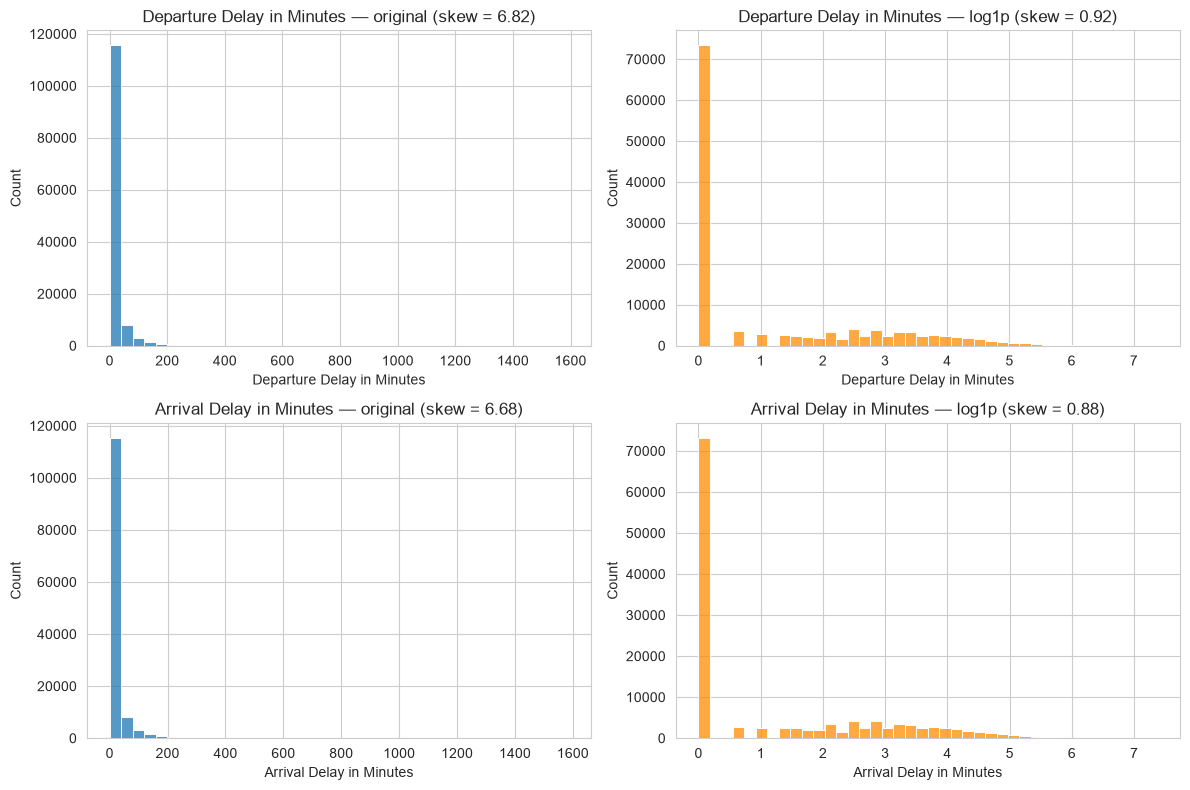

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(delays):
    sns.histplot(X[col], bins=40, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} — original (skew = {X[col].skew():.2f})")
    sns.histplot(np.log1p(X[col]), bins=40, ax=axes[i, 1], color='darkorange')
    axes[i, 1].set_title(f"{col} — log1p (skew = {np.log1p(X[col]).skew():.2f})")
plt.tight_layout()
plt.show()

El skewness se reduce de ≈ 6.8 a menos de 1. Con esta transformación se conservan los valores atípicos identificados en el EDA, que corresponden a demoras reales, sin que dominen la escala.

### Estandarización

Las variables tienen rangos muy distintos (`Flight Distance` hasta ≈ 5000, calificaciones hasta 5). Como PCA es sensible a la escala,
se aplica `StandardScaler` a todas las variables numéricas y a `Class`.

In [ ]:
print(X[continuas + calificaciones[:3]].describe().loc[['mean', 'std', 'min', 'max']].round(2))

        Age  Flight Distance  Inflight wifi service  \
mean  39.43          1190.32                   2.73   
std   15.12           997.45                   1.33   
min    7.00            31.00                   0.00   
max   85.00          4983.00                   5.00   

      Departure/Arrival time convenient  Ease of Online booking  
mean                               3.06                    2.76  
std                                1.53                    1.40  
min                                0.00                    0.00  
max                                5.00                    5.00  


### Pipeline con `ColumnTransformer`

Todas las transformaciones se integran en un único objeto reutilizable para datos nuevos.

In [ ]:
preprocesador = ColumnTransformer(transformers=[
    ('nominales', OneHotEncoder(drop='if_binary', sparse_output=False), nominales),
    ('ordinal', Pipeline([
        ('codificar', OrdinalEncoder(categories=[['Eco', 'Eco Plus', 'Business']])),
        ('escalar', StandardScaler()),
    ]), ordinales),
    ('delays', Pipeline([
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('escalar', StandardScaler()),
    ]), delays),
    ('numericas', StandardScaler(), continuas + calificaciones),
], verbose_feature_names_out=False)

X_prep = pd.DataFrame(preprocesador.fit_transform(X), columns=preprocesador.get_feature_names_out())

print(X_prep.shape)
X_prep.head()

(129880, 22)


,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class,Departure Delay in Minutes,Arrival Delay in Minutes,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness
0,1.0,0.0,1.0,-0.030801,1.251360,1.034388,-1.747961,-0.732184,0.204090,0.617265,...,1.349867,-0.187037,1.181428,1.230787,0.479357,-0.266574,0.311762,0.547894,1.153946,1.304487
1,1.0,1.0,0.0,1.008016,-0.334224,0.421363,-0.954274,-0.957760,0.204090,-0.692719,...,-1.657814,-0.187037,-1.850520,-1.767616,-1.851475,1.252898,-0.535681,-1.821437,0.304086,-1.740402
2,0.0,0.0,0.0,1.008016,-0.762709,-0.773286,-0.888133,-0.048440,-0.548166,-0.692719,...,1.349867,1.293662,1.181428,1.230787,0.479357,-0.266574,0.311762,0.547894,0.304086,1.304487
3,0.0,0.0,0.0,1.008016,0.773394,0.640336,-0.954274,-0.629924,-0.548166,1.272257,...,-0.905894,-0.927386,-1.092533,-1.018015,-1.074531,1.252898,-0.535681,-1.821437,0.304086,-0.979180
4,1.0,0.0,0.0,1.008016,-0.762709,-0.773286,1.426788,-0.978814,0.204090,-0.037727,...,0.597947,1.293662,1.181428,-0.268414,-0.297587,0.493162,0.311762,-0.241883,-0.545774,-0.217958


Verificación del resultado:

In [ ]:
print("Faltantes:", X_prep.isnull().sum().sum())
X_prep.describe().loc[['mean', 'std']].round(2).T

Faltantes: 0


,mean,std
Gender_Male,0.49,0.50
Customer Type_disloyal Customer,0.18,0.39
Type of Travel_Personal Travel,0.31,0.46
Class,0.00,1.00
Departure Delay in Minutes,0.00,1.00
Arrival Delay in Minutes,-0.00,1.00
Age,-0.00,1.00
Flight Distance,0.00,1.00
Inflight wifi service,-0.00,1.00
Departure/Arrival time convenient,-0.00,1.00


El conjunto final tiene 22 columnas numéricas sin faltantes: 3 binarias (sin escalar, para conservar su lectura 0/1) y 19 estandarizadas (media 0, desviación 1).

## 7. Reducción de dimensionalidad con PCA

En el EDA se identificaron variables correlacionadas (`Seat comfort` e `Inflight entertainment`: 0.61; los dos delays: 0.96),
lo que indica información redundante que PCA puede resumir en menos componentes.

### Varianza explicada

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_prep)

varianza = pca.explained_variance_ratio_
acumulada = varianza.cumsum()

tabla_varianza = pd.DataFrame({
    'componente': [f'PC{i+1}' for i in range(len(varianza))],
    'varianza (%)': (varianza * 100).round(2),
    'acumulada (%)': (acumulada * 100).round(2),
})
tabla_varianza.head(12)

,componente,varianza (%),acumulada (%)
0,PC1,20.45,20.45
1,PC2,12.11,32.57
2,PC3,11.15,43.72
3,PC4,9.17,52.89
4,PC5,7.94,60.83
5,PC6,5.16,65.98
6,PC7,4.88,70.86
7,PC8,4.71,75.57
8,PC9,3.53,79.11
9,PC10,3.14,82.24


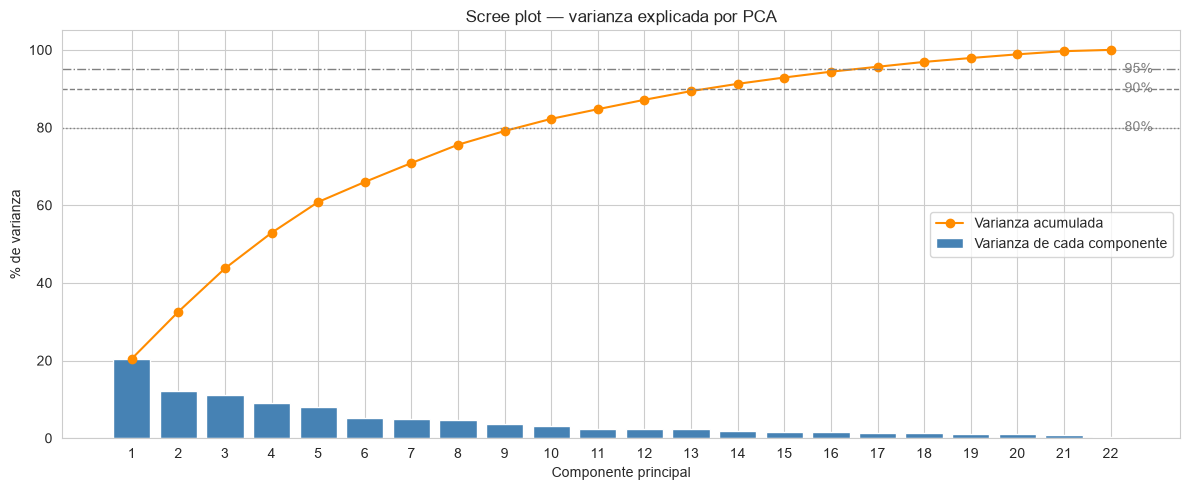

Componentes para 80% de la varianza: 10 de 22
Componentes para 90% de la varianza: 14 de 22
Componentes para 95% de la varianza: 17 de 22


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
componentes = range(1, len(varianza) + 1)
ax.bar(componentes, varianza * 100, color='steelblue', label='Varianza de cada componente')
ax.plot(componentes, acumulada * 100, marker='o', color='darkorange', label='Varianza acumulada')
for umbral, estilo in [(80, ':'), (90, '--'), (95, '-.')]:
    ax.axhline(umbral, color='gray', linestyle=estilo, linewidth=1)
    ax.text(len(varianza) + 0.3, umbral, f'{umbral}%', va='center', color='gray')
ax.set_xlabel('Componente principal')
ax.set_ylabel('% de varianza')
ax.set_xticks(list(componentes))
ax.set_title('Scree plot — varianza explicada por PCA')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

for umbral in [0.80, 0.90, 0.95]:
    n = np.argmax(acumulada >= umbral) + 1
    print(f"Componentes para {umbral:.0%} de la varianza: {n} de {len(varianza)}")

- PC1 explica el 20.5% de la varianza y las dos primeras componentes el 32.6%.
- Se requieren 14 componentes para retener el 90% y 17 para el 95%.
- No se observa un codo marcado: la varianza está distribuida, ya que las preguntas de la encuesta evalúan aspectos distintos del servicio.

### Interpretación de los componentes (loadings)

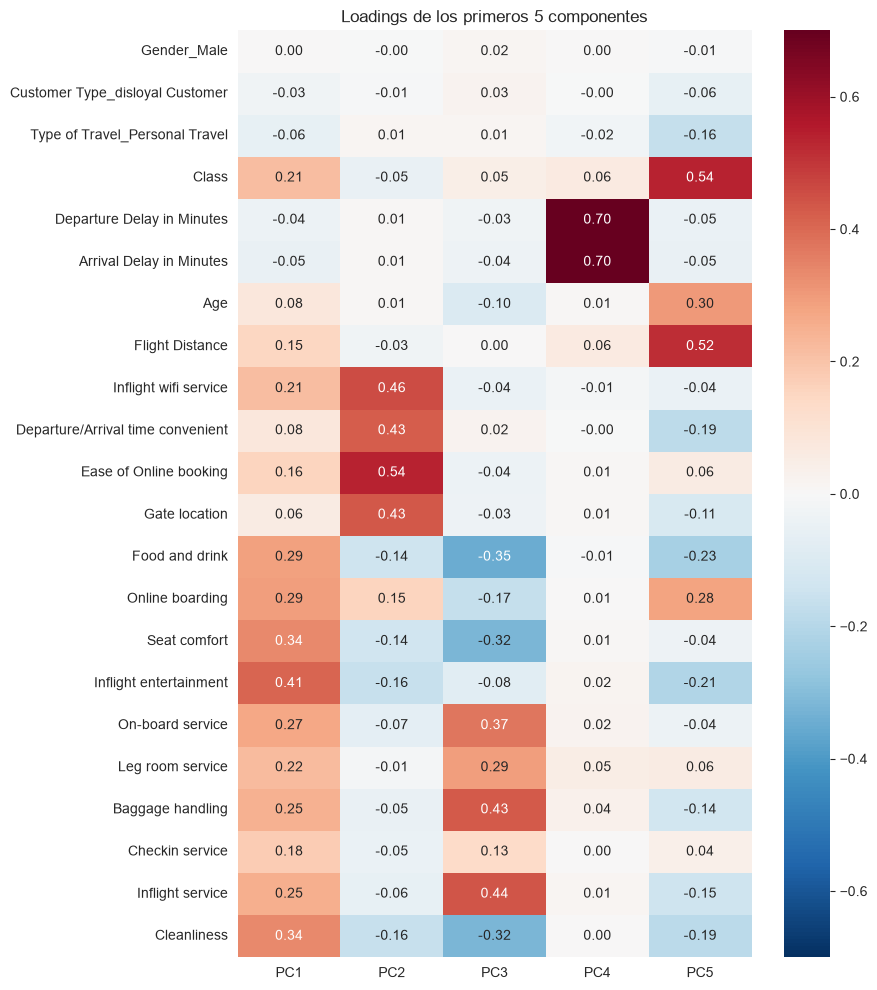

In [ ]:
n_ver = 5
loadings = pd.DataFrame(pca.components_[:n_ver].T,
                        index=X_prep.columns,
                        columns=[f'PC{i+1}' for i in range(n_ver)])

plt.figure(figsize=(9, 10))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7)
plt.title('Loadings de los primeros 5 componentes')
plt.tight_layout()
plt.show()

In [ ]:
for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False).head(4).index
    print(f"{pc}: " + ", ".join(f"{v} ({loadings.loc[v, pc]:+.2f})" for v in top))

PC1: Inflight entertainment (+0.41), Seat comfort (+0.34), Cleanliness (+0.34), Online boarding (+0.29)
PC2: Ease of Online booking (+0.54), Inflight wifi service (+0.46), Gate location (+0.43), Departure/Arrival time convenient (+0.43)
PC3: Inflight service (+0.44), Baggage handling (+0.43), On-board service (+0.37), Food and drink (-0.35)
PC4: Departure Delay in Minutes (+0.70), Arrival Delay in Minutes (+0.70), Class (+0.06), Flight Distance (+0.06)
PC5: Class (+0.54), Flight Distance (+0.52), Age (+0.30), Online boarding (+0.28)


| Componente | Variables con mayor peso | Interpretación |
|---|---|---|
| **PC1** (20.5%) | Inflight entertainment, Seat comfort, Cleanliness, Online boarding, Food and drink | Comodidad y experiencia a bordo |
| **PC2** (12.1%) | Ease of Online booking, Inflight wifi, Gate location, Departure/Arrival time convenient | Conveniencia y servicios digitales/logísticos |
| **PC3** (11.2%) | (+) Inflight service, Baggage handling, On-board service; (−) Food and drink, Seat comfort, Cleanliness | Atención del personal vs. producto a bordo |
| **PC4** (9.2%) | Departure Delay, Arrival Delay | Puntualidad |
| **PC5** (7.9%) | Class, Flight Distance, Age | Perfil del viaje |

Los componentes agrupan las preguntas de la encuesta en dimensiones coherentes del servicio. Los dos delays quedan en un único componente (PC4), lo que confirma su redundancia.

### Proyección en PC1 y PC2

Se grafica una muestra de 10.000 pasajeros para facilitar la lectura.

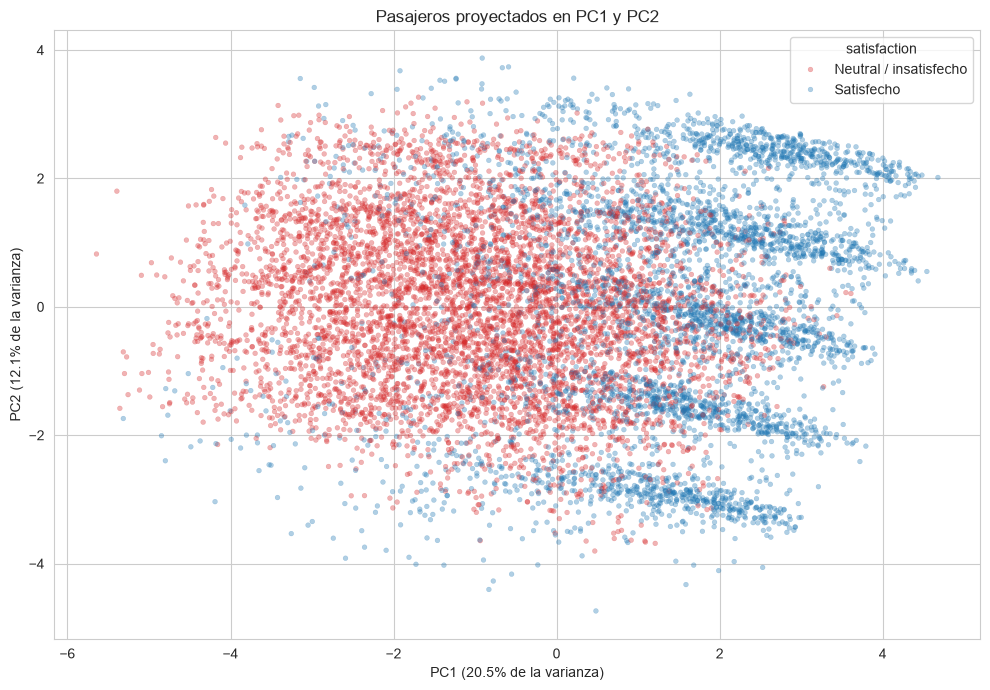

In [ ]:
muestra = X_prep.sample(10000, random_state=42).index
etiquetas = y.loc[muestra].map({0: 'Neutral / insatisfecho', 1: 'Satisfecho'})

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[muestra, 0], y=X_pca[muestra, 1], hue=etiquetas,
                palette={'Neutral / insatisfecho': 'tab:red', 'Satisfecho': 'tab:blue'},
                alpha=0.35, s=12, edgecolor=None)
plt.xlabel(f'PC1 ({varianza[0]:.1%} de la varianza)')
plt.ylabel(f'PC2 ({varianza[1]:.1%} de la varianza)')
plt.title('Pasajeros proyectados en PC1 y PC2')
plt.legend(title='satisfaction')
plt.tight_layout()
plt.show()

Se observa separación entre grupos a lo largo de PC1; PC2 no discrimina entre satisfechos e insatisfechos.
Las franjas diagonales se deben a que las calificaciones toman valores enteros.

Promedio de cada componente por grupo:

In [ ]:
pd.DataFrame(X_pca[:, :5], columns=[f'PC{i+1}' for i in range(5)]).groupby(y.values).mean().round(2).rename(
    index={0: 'Neutral / insatisfecho', 1: 'Satisfecho'})

,PC1,PC2,PC3,PC4,PC5
Neutral / insatisfecho,-1.03,0.02,-0.04,0.02,-0.35
Satisfecho,1.34,-0.03,0.06,-0.02,0.45


- **PC1:** +1.34 en satisfechos frente a −1.03 en insatisfechos. La comodidad a bordo es la dimensión que más diferencia a los grupos.
- **PC2, PC3 y PC4:** valores cercanos a 0 en ambos grupos; no diferencian la satisfacción por sí solos.
- **PC5:** diferencia moderada (+0.45 vs. −0.35), consistente con el EDA (69% de satisfechos en Business frente a 19% en Eco).

### Biplot

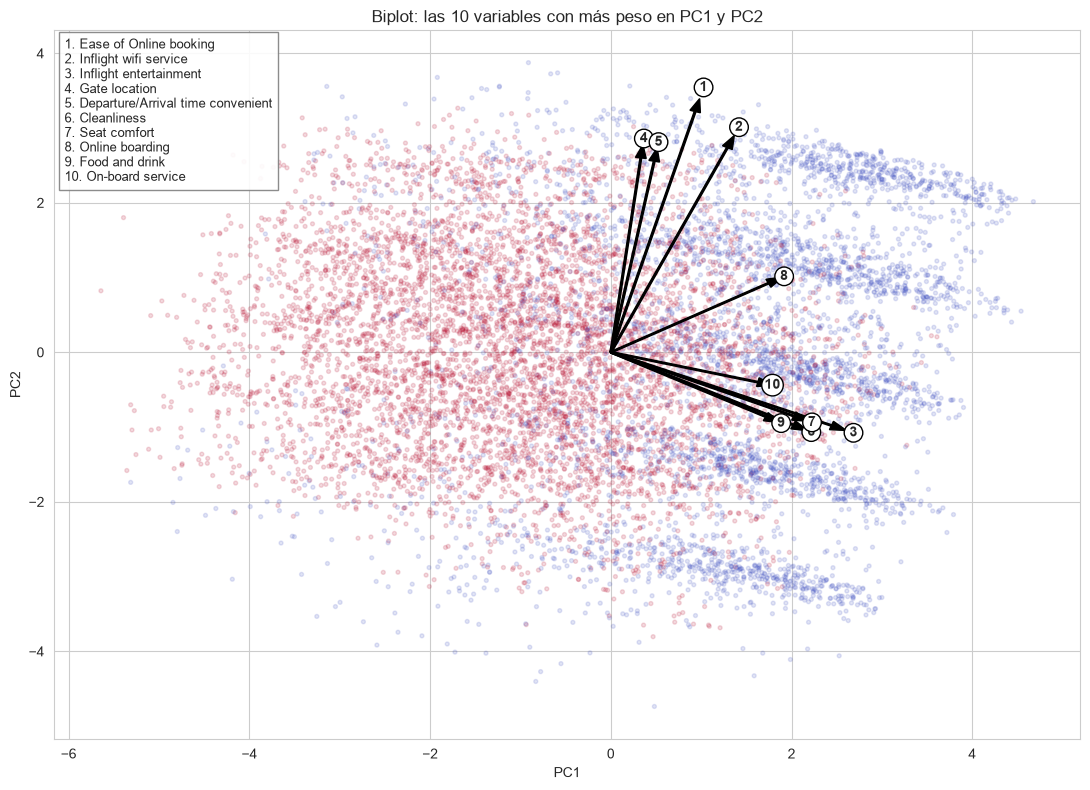

In [ ]:
plt.figure(figsize=(11, 8))
plt.scatter(X_pca[muestra, 0], X_pca[muestra, 1], c=y.loc[muestra], cmap='coolwarm_r', alpha=0.15, s=8)

escala = 6
top_vars = (loadings[['PC1', 'PC2']] ** 2).sum(axis=1).sort_values(ascending=False).head(10).index
# Flechas numeradas con leyenda para evitar superposición de etiquetas
leyenda = []
for n, var in enumerate(top_vars, start=1):
    lx, ly = loadings.loc[var, 'PC1'] * escala, loadings.loc[var, 'PC2'] * escala
    plt.arrow(0, 0, lx, ly, color='black', width=0.02, head_width=0.12)
    plt.text(lx * 1.1, ly * 1.1, str(n), fontsize=10, fontweight='bold', ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle,pad=0.2'))
    leyenda.append(f"{n}. {var}")
plt.text(0.01, 0.99, "\n".join(leyenda), transform=plt.gca().transAxes, fontsize=9, va='top',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot: las 10 variables con más peso en PC1 y PC2')
plt.tight_layout()
plt.show()

Las variables de experiencia a bordo (entretenimiento, asiento, limpieza, comida, online boarding) apuntan hacia la región de satisfechos.
Las de conveniencia (reserva online, wifi, ubicación de la puerta, horario) apuntan en la dirección de PC2, que no separa los grupos.
Las flechas 6 y 7 se superponen porque sus loadings son prácticamente iguales.